# Install and import libraries

In [ ]:
!pip install scanpy anndata torch umap-learn seaborn leidenalg --quiet

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

# Load PBMC3K dataset

In [ ]:
adata = sc.datasets.pbmc3k()

print("Dataset Loaded Successfully\n")

print("Dataset Shape:", adata.shape)
print("Number of Cells:", adata.n_obs)
print("Number of Genes:", adata.n_vars)

print("\nMetadata Columns:")
print(adata.obs.columns.tolist())

Dataset Loaded Successfully

Dataset Shape: (2700, 32738)
Number of Cells: 2700
Number of Genes: 32738

Metadata Columns:
[]


#Basic Clustering

In [ ]:
# Preprocessing required before clustering labels exist

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

adata = adata[:, adata.var.highly_variable]

# PCA
sc.tl.pca(adata)

# Neighbors + clustering
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# Check available labels
print("Available metadata columns:")
print(adata.obs.columns.tolist())

# label column
label_column = 'leiden'


print(f"\nUsing label column: {label_column}")

Available metadata columns:
['leiden']

Using label column: leiden


# PCA feature extraction

In [ ]:
# Convert sparse matrix to dense
X_dense = adata.X.toarray()

# PCA Reduction
pca = PCA(n_components=100)

X = pca.fit_transform(X_dense)

# Labels
y = adata.obs[label_column].values

print("Original Shape:", X_dense.shape)
print("Final PCA Shape:", X.shape)

print("\nExplained Variance Ratio:")
print(np.sum(pca.explained_variance_ratio_))

Original Shape: (2700, 2000)
Final PCA Shape: (2700, 100)

Explained Variance Ratio:
0.42597294


#Encode labels + Train/Test Split

In [ ]:
# Encode labels
le = LabelEncoder()

y_encoded = le.fit_transform(y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

print("\nNumber of Classes:", len(le.classes_))

print("\nClass Names:")
print(le.classes_)

Train Shape: (2160, 100)
Test Shape: (540, 100)

Number of Classes: 9

Class Names:
['0' '1' '2' '3' '4' '5' '6' '7' '8']


#Baseline Model 1 (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Accuracy:", acc_knn)
print("KNN F1 Score:", f1_knn)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.5666666666666667
KNN F1 Score: 0.5344211803253364

Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.89      0.56       124
           1       0.53      0.56      0.55       100
           2       0.86      0.62      0.72        98
           3       0.80      0.11      0.20        72
           4       0.89      0.44      0.59        70
           5       0.79      0.91      0.85        33
           6       0.00      0.00      0.00        31
           7       1.00      0.78      0.88         9
           8       1.00      1.00      1.00         3

    accuracy                           0.57       540
   macro avg       0.70      0.59      0.59       540
weighted avg       0.64      0.57      0.53       540



#Baseline Model 2 (Random Forest)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Accuracy:", acc_rf)
print("Random Forest F1 Score:", f1_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.924074074074074
Random Forest F1 Score: 0.9220845714028669

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       124
           1       0.90      0.83      0.86       100
           2       0.96      0.98      0.97        98
           3       0.93      0.90      0.92        72
           4       0.97      1.00      0.99        70
           5       0.94      0.94      0.94        33
           6       0.94      1.00      0.97        31
           7       1.00      0.44      0.62         9
           8       1.00      1.00      1.00         3

    accuracy                           0.92       540
   macro avg       0.95      0.89      0.91       540
weighted avg       0.92      0.92      0.92       540



# Device setup

In [ ]:
device = torch.device("cpu")

print("Using Device:", device)

input_dim = X_train_scaled.shape[1]
num_classes = len(le.classes_)

print("Input Dimension:", input_dim)
print("Number of Classes:", num_classes)

Using Device: cpu
Input Dimension: 100
Number of Classes: 9


#Deep learning architecture

In [ ]:
class CellClassifier(nn.Module):

    def __init__(self, input_dim, num_classes):
        super(CellClassifier, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

model = CellClassifier(input_dim, num_classes).to(device)

print(model)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())

print(f"\nTotal Parameters: {total_params:,}")

CellClassifier(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=9, bias=True)
  )
)

Total Parameters: 218,889


#Convert Data to Tensors

In [ ]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
).to(device)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
).to(device)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
).to(device)

#DataLoader

In [ ]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

#Training Setup

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 50

train_losses = []
val_accuracies = []

#Training Loop

In [ ]:
for epoch in range(epochs):

    # TRAIN MODE
    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    # EVALUATION
    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor)

        _, preds = torch.max(outputs, 1)

        val_acc = accuracy_score(
            y_test,
            preds.cpu().numpy()
        )

    val_accuracies.append(val_acc)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Accuracy: {val_acc:.4f}"
        )

Epoch [10/50] | Loss: 0.0631 | Val Accuracy: 0.9241
Epoch [20/50] | Loss: 0.0287 | Val Accuracy: 0.9278
Epoch [30/50] | Loss: 0.0136 | Val Accuracy: 0.9259
Epoch [40/50] | Loss: 0.0152 | Val Accuracy: 0.9222
Epoch [50/50] | Loss: 0.0073 | Val Accuracy: 0.9185


#Deep Learning Evaluation

In [ ]:
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    _, preds = torch.max(outputs, 1)

y_pred_dl = preds.cpu().numpy()

acc_dl = accuracy_score(y_test, y_pred_dl)

f1_dl = f1_score(
    y_test,
    y_pred_dl,
    average='weighted'
)

print("Deep Learning Accuracy:", acc_dl)

print("Deep Learning F1 Score:", f1_dl)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_dl
))

Deep Learning Accuracy: 0.9185185185185185
Deep Learning F1 Score: 0.917345093940589

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       124
           1       0.87      0.82      0.85       100
           2       0.96      0.99      0.97        98
           3       0.90      0.89      0.90        72
           4       0.99      1.00      0.99        70
           5       0.97      0.97      0.97        33
           6       0.97      0.94      0.95        31
           7       1.00      0.56      0.71         9
           8       1.00      1.00      1.00         3

    accuracy                           0.92       540
   macro avg       0.95      0.90      0.91       540
weighted avg       0.92      0.92      0.92       540



#Results comparison table

In [ ]:
results_df = pd.DataFrame({

    "Model": [
        "KNN",
        "Random Forest",
        "Deep Learning"
    ],

    "Accuracy": [
        acc_knn,
        acc_rf,
        acc_dl
    ],

    "F1 Score": [
        f1_knn,
        f1_rf,
        f1_dl
    ]
})

print(results_df)

           Model  Accuracy  F1 Score
0            KNN  0.566667  0.534421
1  Random Forest  0.924074  0.922085
2  Deep Learning  0.918519  0.917345


#Accuracy comparison plot

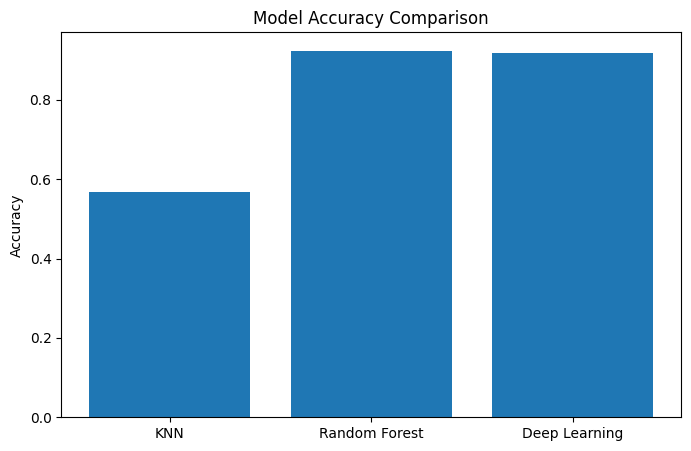

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.grid(False)

plt.savefig("accuracy_comparison.png")

plt.show()

#F1 Score Comparison Plot

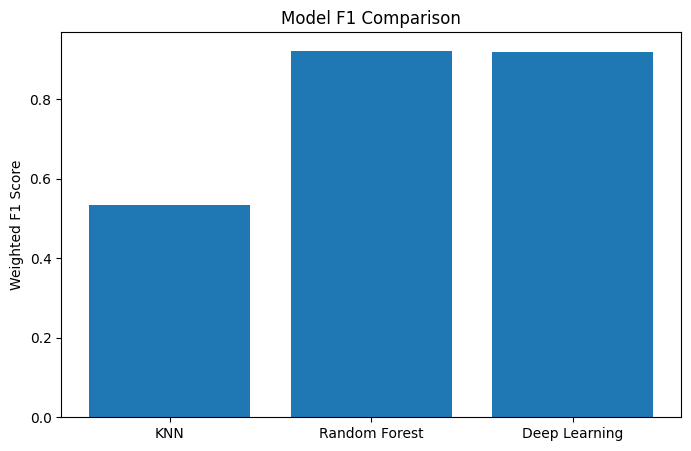

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.ylabel("Weighted F1 Score")
plt.title("Model F1 Comparison")

plt.grid(False)

plt.savefig("f1_comparison.png")

plt.show()

#Confusion matrix

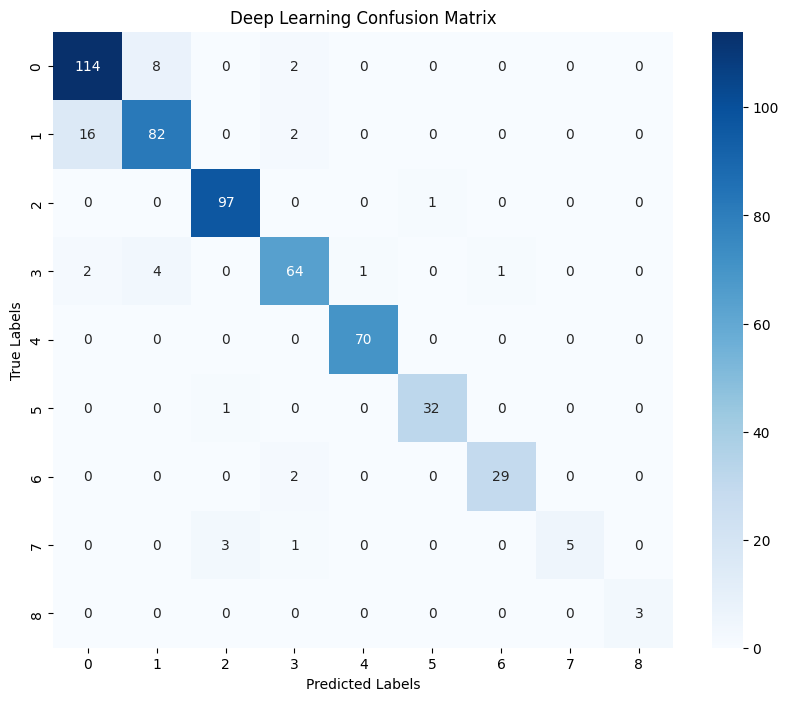

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_dl
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.title("Deep Learning Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

#Training curves

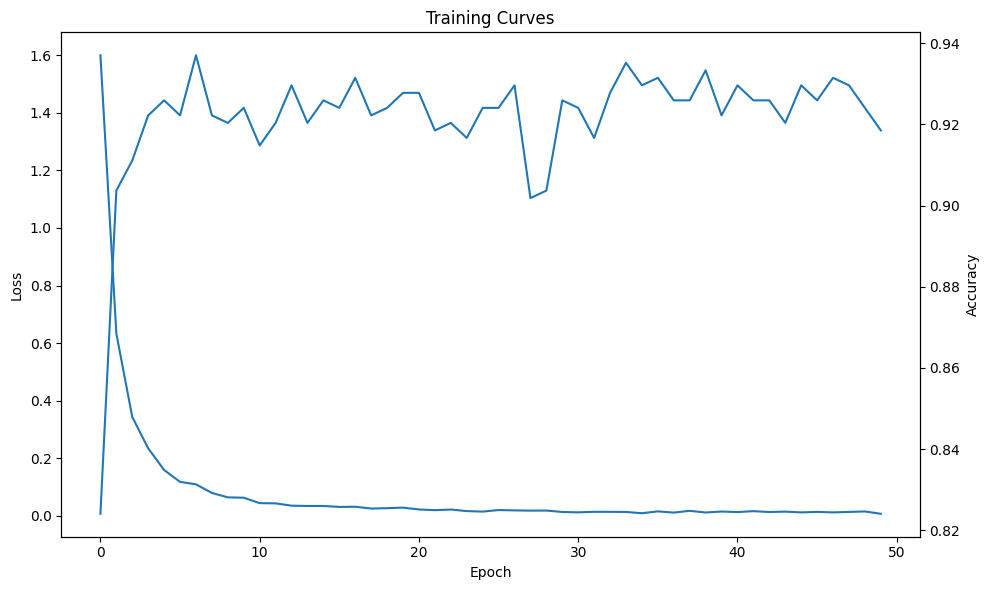

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Loss
ax1.plot(
    train_losses,
    label='Training Loss'
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Accuracy
ax2 = ax1.twinx()

ax2.plot(
    val_accuracies,
    label='Validation Accuracy'
)

ax2.set_ylabel("Accuracy")

plt.title("Training Curves")

fig.tight_layout()

plt.savefig("training_curves.png")

plt.show()

#Per class performance analysis

In [ ]:
report_dict = classification_report(
    y_test,
    y_pred_dl,
    target_names=le.classes_,
    output_dict=True
)

class_metrics = []

for class_name in le.classes_:

    metrics = report_dict[class_name]

    class_metrics.append({

        "Cluster": class_name,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1-score"],
        "Support": metrics["support"]
    })

class_df = pd.DataFrame(class_metrics)

class_df = class_df.sort_values(
    by="F1",
    ascending=False
)

print(class_df)

  Cluster  Precision    Recall        F1  Support
8       8   1.000000  1.000000  1.000000      3.0
4       4   0.985915  1.000000  0.992908     70.0
2       2   0.960396  0.989796  0.974874     98.0
5       5   0.969697  0.969697  0.969697     33.0
6       6   0.966667  0.935484  0.950820     31.0
3       3   0.901408  0.888889  0.895105     72.0
0       0   0.863636  0.919355  0.890625    124.0
1       1   0.872340  0.820000  0.845361    100.0
7       7   1.000000  0.555556  0.714286      9.0


#Per class metrics plot

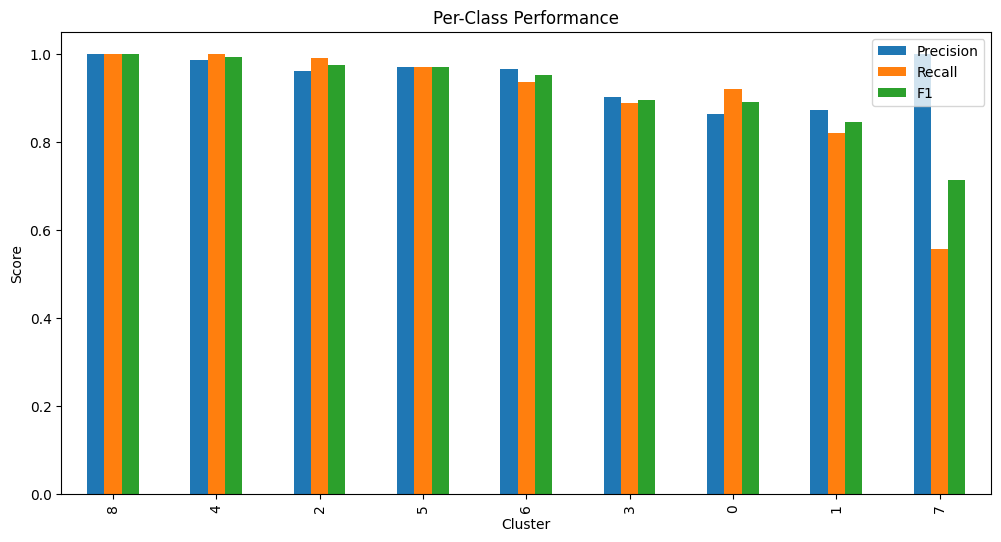

In [ ]:
class_df.plot(
    x='Cluster',
    y=['Precision', 'Recall', 'F1'],
    kind='bar',
    figsize=(12,6)
)

plt.title("Per-Class Performance")
plt.ylabel("Score")
plt.savefig("per_class_metrics.png")

plt.show()